# Learning ANN

## Uinsg MNIST dataset

In [1]:
%load_ext cudf.pandas
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arnavsharma45/mnist-dataset/mnist_dataset.csv")
df.head(10)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print(df.shape)
print(df.isna().sum().sum())

(42000, 784)
0


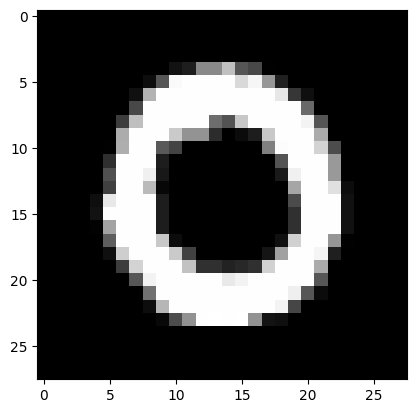

In [4]:
# getting the photos out of the data
import matplotlib.pyplot as plt

# img = df.iloc[0, :].values.reshape(28,28)            # This is the syntax if you are running the code on normal CPU, since we are using pandas from 'cudf', so we just have to write 'to_numpy()'
img = df.iloc[1, :].tolist()
img = np.array(img).reshape(28,28)

plt.imshow(img, cmap='gray')
plt.show()




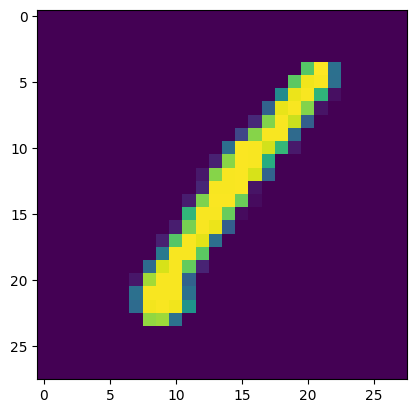

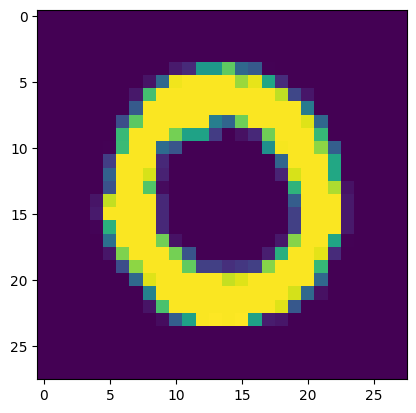

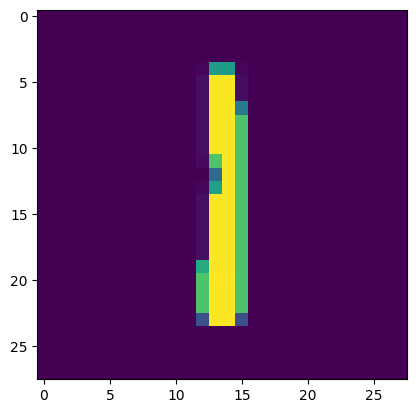

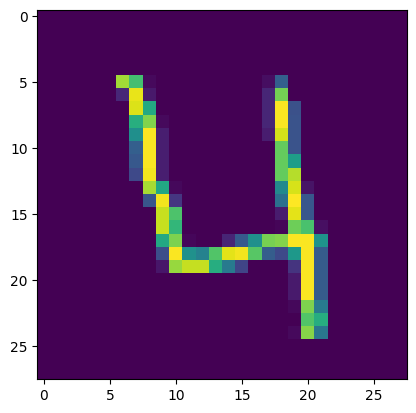

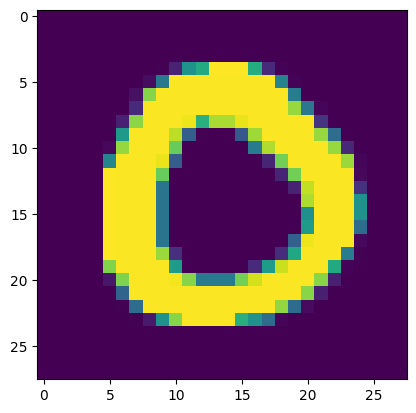

In [5]:
for i in np.arange(0,5):
    list = df.loc[i, :].tolist()
    img = np.array(list).reshape(28,28)
    plt.imshow(img)
    plt.show()

In [6]:
df.shape

(42000, 784)

In [7]:
df.iloc[0]

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 0, Length: 784, dtype: int64

### Since this MNIST dataset donot have an output feature, we will be import MNIST dataset from `keras`

In [8]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

2026-05-16 17:50:51.039115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778953851.253783      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778953851.326752      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778953851.846705      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778953851.846740      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778953851.846743      57 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
x_test.shape       # this is a 3D dataset

(10000, 28, 28)

In [10]:
y_train      # this is the output feature, it contains the number written in the photo

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

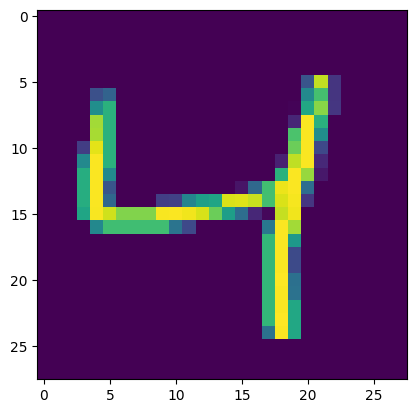

In [14]:
import matplotlib.pyplot as plt
plt.imshow(x_train[2])

In [39]:
# using scaling before proceed with ANN, to bring all the data in a range -- using scaler
# sicne this is a 3D dataset, we cant use MinMaxScaler, we have to scale it manually

x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0


In [40]:
print(x_train_scaled.shape)
x_train_scaled

(60000, 28, 28)


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [41]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [43]:
import tensorflow
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
model = models.Sequential([
    # since this is a 3D dataset we have to flatten it first
    layers.Flatten(input_shape=(28,28)),

    # layer 1
    layers.Dense(130, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    layers.Dropout(0.3),

    # layer 2
    layers.Dense(80, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    layers.Dropout(0.3),

    # layer 3
    layers.Dense(30, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    layers.Dropout(0.3),

    # layer 4
    layers.Dense(10, activation='softmax', kernel_regularizer=regularizers.l1(0.001))    
    
])

In [54]:
# using early stopping
early_stopping = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.01,
    patience=5,
    mode='auto',
    restore_best_weights=True
)
    

In [55]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [56]:
history = model.fit(x_train, y_train, epochs=150, batch_size=64, callbacks=[early_stopping], validation_data=[x_test, y_test])

Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8907 - loss: 0.8224 - val_accuracy: 0.9448 - val_loss: 0.6322
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8991 - loss: 0.8102 - val_accuracy: 0.9469 - val_loss: 0.6202
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8982 - loss: 0.8027 - val_accuracy: 0.9485 - val_loss: 0.6291
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9019 - loss: 0.7906 - val_accuracy: 0.9516 - val_loss: 0.5923
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9001 - loss: 0.7901 - val_accuracy: 0.9435 - val_loss: 0.6182
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9035 - loss: 0.7874 - val_accuracy: 0.9481 - val_loss: 0.6049
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9025 - loss: 0.7830 - val_accuracy: 0.9490 - val_loss: 0.6252
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9043 - loss: 0.7866 - val_accu

## Understanding Training Logs in Keras

### 1. The Timeline
*   **`Epoch 9/150`**: The model is on its **9th pass** through the entire dataset. It will repeat this 150 times.
*   **`938/938`**: This represents the **Steps (Batches)**. 
    *   Formula: `Total Samples / Batch Size = Total Steps`.
    *   The model updates its weights 938 times per epoch.
*   **`3s`**: Total time taken to complete the entire epoch.
*   **`3ms/step`**: Average time taken to process a single batch of data.

---

### 2. Training Metrics (The "Learning" Phase)
These values are calculated **while** the model is looking at the training data and updating its weights.
*   **`accuracy` (0.9039)**: 
    *   **Meaning**: The percentage of training images correctly predicted.
    *   **Analysis**: 90.39% accuracy means the model is learning the patterns well.
*   **`loss` (0.7835)**: 
    *   **Meaning**: The "Cost" or "Error" of the model. 
    *   **Analysis**: As the model learns, this number should go **down** over time.

---

### 3. Validation Metrics (The "Testing" Phase)
These values are calculated **after** the epoch ends, using data the model has never seen before.
*   **`val_accuracy` (0.9432)**:
    *   **Meaning**: The percentage of "unseen" images correctly predicted.
    *   **Analysis**: This is the most important number. 94.32% is the "Real World" accuracy.
*   **`val_loss` (0.6455)**:
    *   **Meaning**: The "Error" on the new data.
    *   **Analysis**: If this starts going **up** while training loss goes down, your model is **overfitting**.

---

### 4. Important Tip: The "Dropout Effect"
In your logs, **`val_accuracy`** is higher than **`accuracy`**. 
*   **Why?** During training, **Dropout** randomly "turns off" neurons to make the model study harder. 
*   **During Validation**, Dropout is turned **OFF**. The model is now at full strength, which is why it performs better on the test!


In [59]:
prediction = model.predict(x_test)
prediction = prediction.argmax(axis=1)
prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [63]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

print(f"ACCURACY SCORE : {np.round(accuracy_score(prediction, y_test),2)*100} %")
print(f"F1 SCORE : {np.round(f1_score(prediction, y_test, average='weighted'),2)*100} %")
print(f"PRECISION SCORE : {np.round(precision_score(prediction, y_test, average='weighted'),2)*100} %")
print(f"RECALL SCORE : {np.round(recall_score(prediction, y_test, average='weighted'),2)*100} %")

ACCURACY SCORE : 95.0 %
F1 SCORE : 95.0 %
PRECISION SCORE : 95.0 %
RECALL SCORE : 95.0 %


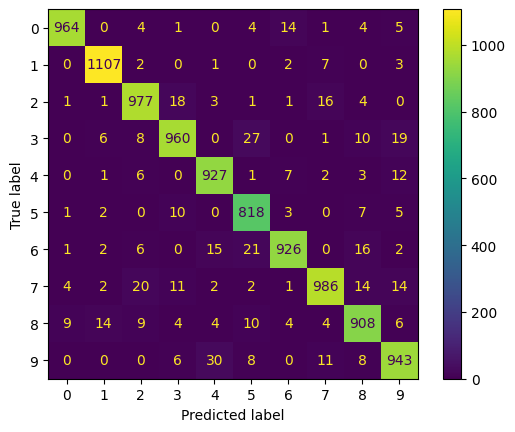

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

matrix = confusion_matrix(prediction, y_test)
labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

graph = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels) 
graph.plot()
plt.show()


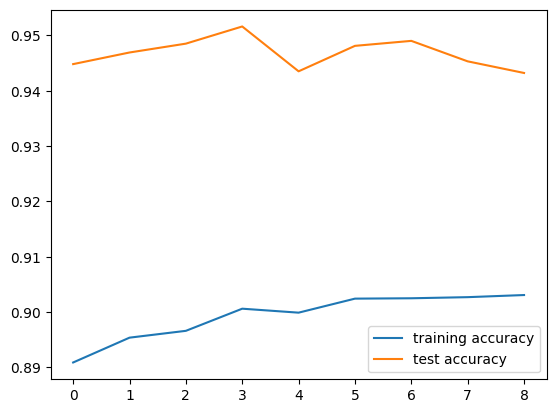

In [72]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.show()

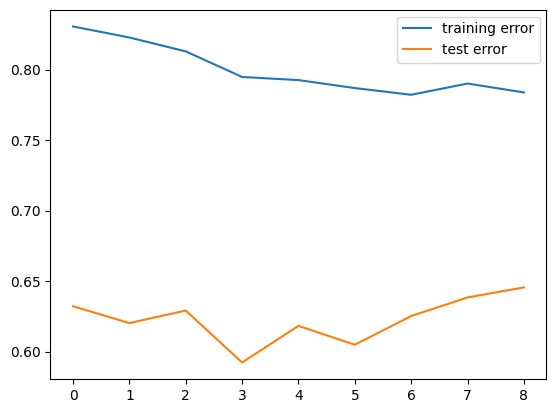

In [74]:
plt.plot(history.history['loss'], label='training error')
plt.plot(history.history['val_loss'], label='test error')
plt.legend()
plt.show()